In [1]:
import networkx as nx
import numpy as np
import random
import matplotlib.pyplot as plt

shuffled V : 
 [10, 2, 5, 3, 11, 0, 4, 1, 6, 9, 8, 7]
random sample :
 [3, 9, 7, 6] 

# edges:20
# nodes:12


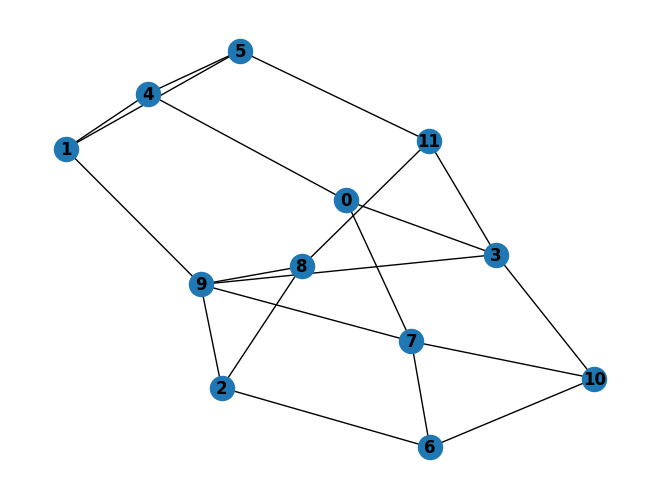

In [2]:
# לא רלוונטי לעבודה
N = 12
G = nx.random_regular_graph(3, N)
V = [node for node in G.nodes()]
random.shuffle(V)
print(f"shuffled V : \n {V}")
V = random.sample(V,k=2*int(1 + random.random()*(N/2-1)))
print(f"random sample :\n {V} \n")
for i in range(len(V)//2):
  G.add_edge(V[i],V[i+1])
nx.draw(G, with_labels=True, font_weight='bold')
print(f"# edges:{G.number_of_edges()}")
print(f"# nodes:{G.number_of_nodes()}")

In [3]:
# excercice
N1 = 41
G1 = nx.complete_graph(N1)
print(f"# edges:{G1.number_of_edges()}")
print(f"# nodes:{G1.number_of_nodes()}")

# edges:820
# nodes:41


[4, 1, 4, 0, 0, 0, 4, 6, 0, 1]


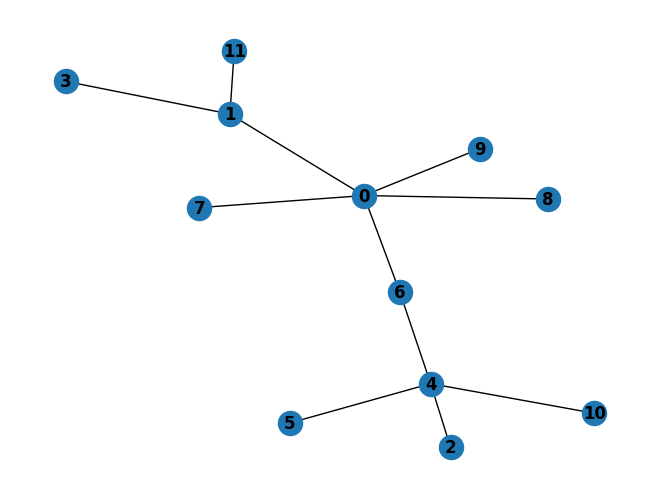

In [4]:
N2 = 10
code = [int(random.random()*(N2-1))for i in range(N2)]
print(code)
decoding = nx.from_prufer_sequence(code)
nx.draw(decoding, with_labels=True, font_weight='bold')

First algorithm

In [5]:
def r_regular_1(N=10,r=4):
  # initializing an empty graph
  G = nx.Graph()
  # initializing a vertex set of size N
  V = [i for i in range(N)]
  # randomly permutating the vertices
  random.shuffle(V)
  # dividing all the vertices to two groups V1,V2
  V1 = V[:N//2]
  V2 = V[N//2:]
  # iterating over all vertices
  for i in range(N//2):
    # connecting every 2 consecutive vertices in each of the subsets V1,V2 to form a cycle graph (K2)
    G.add_edge(V1[(i)%(N//2)],V1[(i+1)%(N//2)])
    G.add_edge(V2[(i)%(N//2)],V2[(i+1)%(N//2)])
    # matching consecutively a vertex from V1 to a vertex in V2
    for j in range(r-3+1): # practically preforming r-3 iterations...
      # simulating a cyclic permutation and repeating the previous step
      G.add_edge(V1[(i)%(N//2)],V2[(i+j)%(N//2)])
  return G,(r-2)*(N//2) # number of iterations is dictated by N and r in a constant formula

10


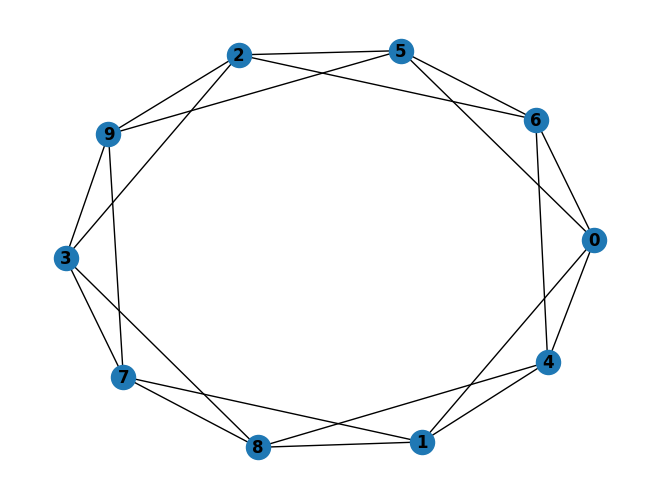

In [6]:
G1,iterations = r_regular_1()
G1_ = nx.complement(G1)
nx.draw(G1, with_labels=True, font_weight='bold')
# nx.draw(G1_, with_labels=True, font_weight='bold')
print(iterations)

Second algorithm

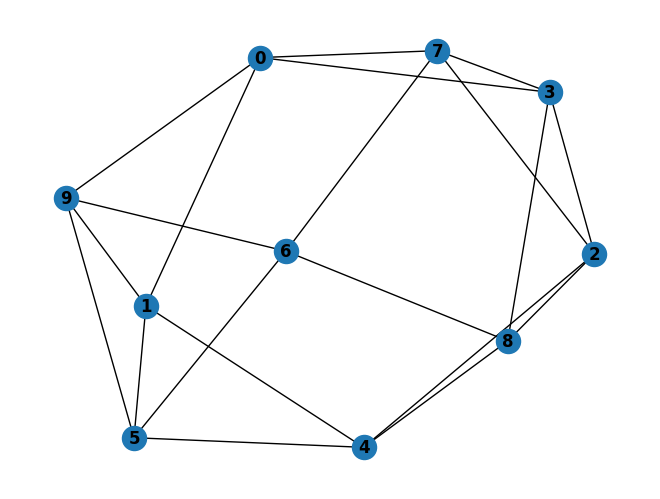

In [7]:
def r_regular_2(N = 10, r = 4):
    total_nodes = N * r
    iterations = 0 # keeping track of number of iterations for later subsections
    while True:
        iterations +=1
        # init. an empty graph containing all nodes {1...N*r}
        G = nx.Graph()
        G.add_nodes_from(range(total_nodes))

        # random partition to groups of size r
        nodes = list(G.nodes())
        random.shuffle(nodes)
        groups = [nodes[i * r:(i + 1) * r] for i in range(N)]

        # init. variables for random matching between all the nodes
        matching_edges = []
        available_nodes = set(nodes)
        attempts = 0

        while len(matching_edges) < total_nodes // 2 and attempts < 1000:
            if attempts ==999 : print("impossible graph or low probability")
            u, v = random.sample(sorted(available_nodes), 2) # sampling randomly to assure random matching
            matching_edges.append((u, v)) # add the edge to the current matching of the iteration
            available_nodes.remove(u)
            available_nodes.remove(v)
            attempts += 1

        # if the number of edges is less than half the nodes,
        # that means that there is at least one unmatched node
        # therefore, not enough edges to justify the matching and we continue to the next iteration
        if len(matching_edges) < total_nodes // 2:
            continue

        # adding all new matchings to the graph
        G.add_edges_from(matching_edges)

        # we take each group and combine all nodes inside it to a single node
        # thats connected the all the nodes that the nodes in the group were connected to
        H = nx.Graph()
        group_map = {}
        # we map each node to it's group via hashmap
        for i, group in enumerate(groups):
            for node in group:
                group_map[node] = i
            H.add_node(i)

        # we assure that every matching is valid so we iterate over the matchings and verify the following:
        invalid = False
        for u, v in matching_edges:
            group_u = group_map[u]
            group_v = group_map[v]

            # if a matching contains two nodes from the same group,
            # the matching is invalid and we need to enter another iteration
            # until we get matchings only between different groups
            if group_u == group_v:
                invalid = True
                break


            # if a matching yields 2 edges between 2 groups then
            # the matching is invalid and we need to enter another iteration
            # until we get unique matchings between groups
            if H.has_edge(group_u, group_v):
                invalid = True
                break


            H.add_edge(group_u, group_v)

        if invalid:
            continue

        # reassuring that the graph is r-reglular as requested
        if all(deg == r for _, deg in H.degree()):
            return H,iterations

G,iterations = r_regular_2()
nx.draw(G, with_labels=True, font_weight='bold')

0.02109670639038086


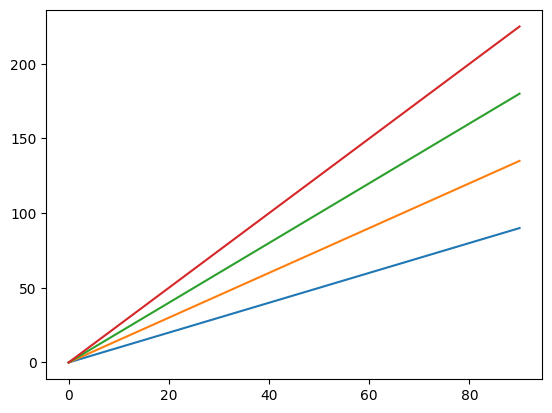

In [8]:
import time
iter_list = []
start = time.time()
N = 10
r = 8
for j in range(4,r):
  iterations_j = []
  for i in range(N):
    G1,iterations = r_regular_1(10*i,j)
    iterations_j.append(iterations)
  iter_list.append(iterations_j)
end = time.time()
print(end - start)
plt.Figure()
for iter_j in iter_list:
  X = [10*i for i in range(10)]
  Y = iter_j
  plt.plot(X,Y)

In [ ]:
N = 5
R = 8
iter_array = np.zeros((R-4,N)) # r=4,5,6 ; N=20,40,60,80,100
for r in range(R-4,R): # iterating over all degrees - R
  for n in range(1,N+1): # SUBSECTION iterating over all total number of nodes - N
    G2,iterations = r_regular_2(10*n,r)
    iter_array[r-(R-4),n-1] = iterations
print(iter_array)

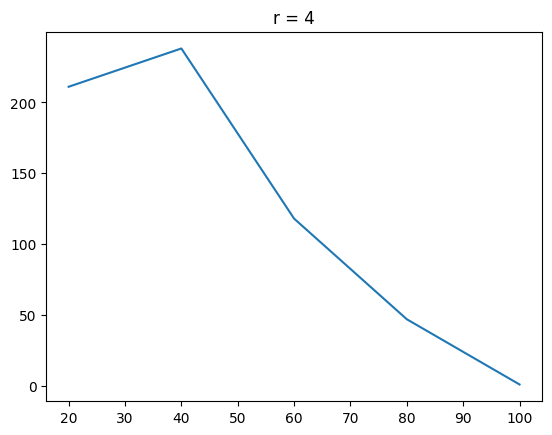

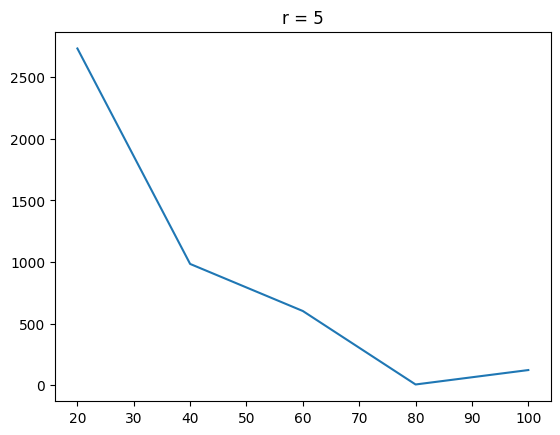

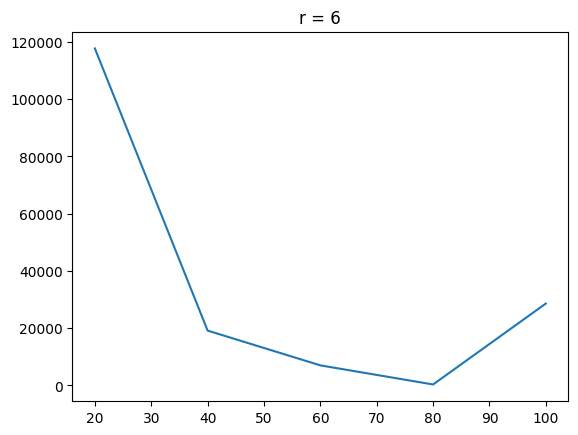

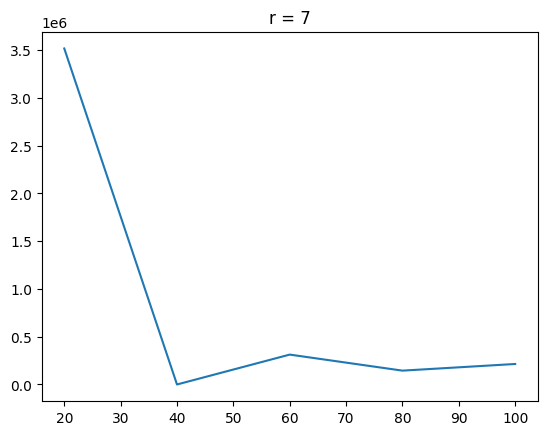

In [ ]:
for i,iters in enumerate(iter_array) :
  X = [i for i in range(20,101,20)]
  Y = iters
  plt.figure()
  plt.plot(X,Y)
  plt.title(f"r = {i + 4}")

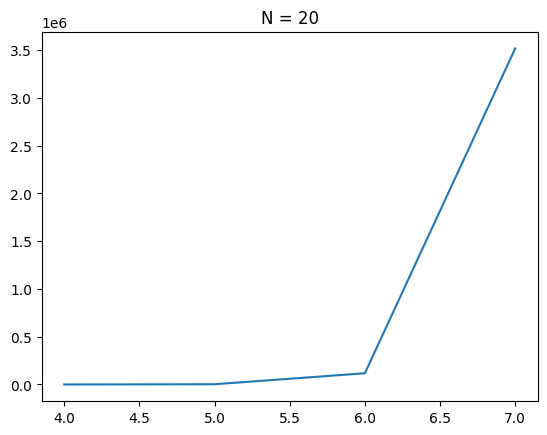

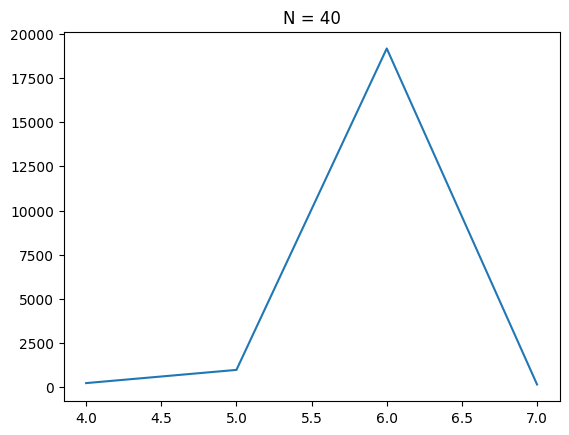

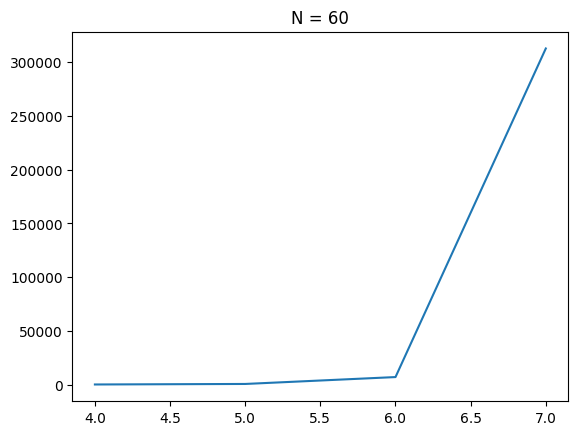

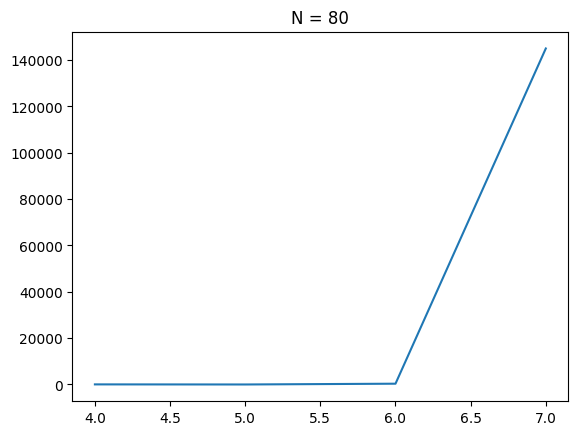

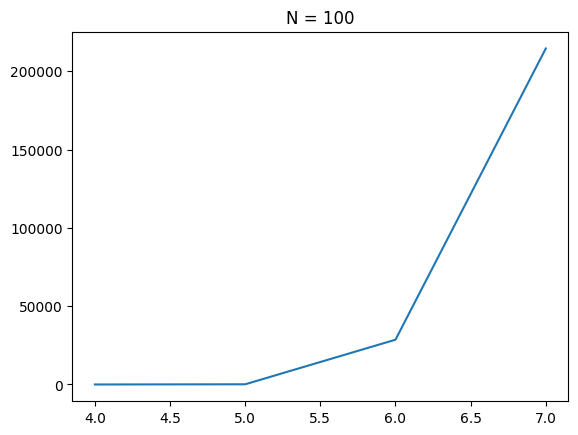

In [ ]:
for i,iters in enumerate(iter_array.T) :
  X = [i for i in range(4,8)]
  Y = iters
  plt.figure()
  plt.plot(X,Y)
  plt.title(f"N = {(i+1)*20}")

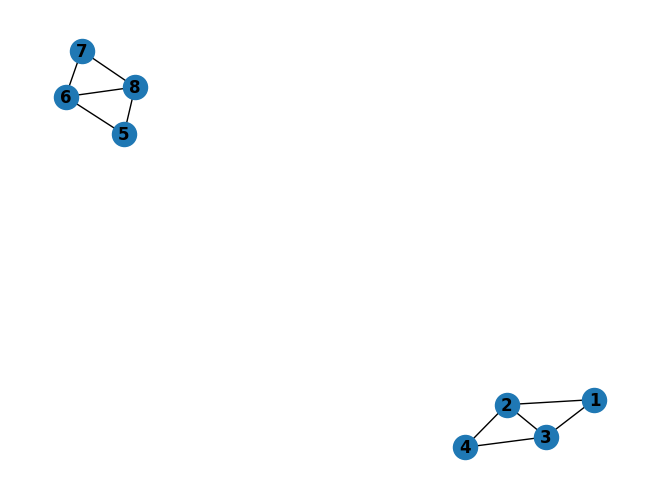

In [ ]:
E = [(1,2),(1,3),(3,2),(4,2),(3,4),(5,6),(5,8),(6,7),(6,8),(7,8)]
G = nx.Graph(E)
nx.draw(G, with_labels=True, font_weight='bold')


True


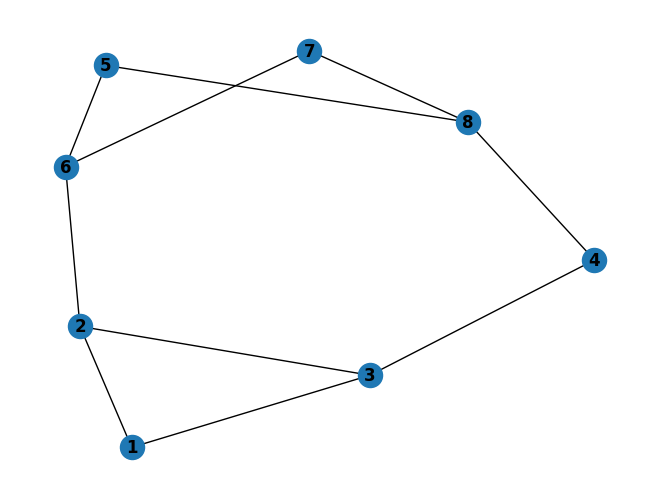

In [ ]:
H = G.copy()
H.remove_edge(2,4)
H.remove_edge(6,8)

H.add_edge(2,6)
H.add_edge(8,4)

nx.draw(H, with_labels=True, font_weight='bold')

same_deg = True
for v in G.nodes():
  if G.degree(v) != H.degree(v):
    same_deg = False
print(same_deg)


In [ ]:
N = 12
K = N//4
V =[i for i in range(N)]
partition_indices = [0] + random.sample(V,k=K) + [N-1]
partition_indices.sort()
node_sets = [V[partition_indices[j]:partition_indices[j+1]] for j in range(len(partition_indices)-1)]
print(partition_indices)
print(node_sets)
Trees = []
for V_ in node_sets :
  new_tree = nx.random_unlabeled_tree(len(V_))
  dic = dict(zip(new_tree.nodes() , V_))
  nx.relabel_nodes(new_tree,dic)
  Trees.append( new_tree)

Forest = nx.union_all(Trees)
# nx.draw(Trees[0], with_labels=True, font_weight='bold')
# nx.draw(Trees[1], with_labels=True, font_weight='bold')

[0, 0, 2, 4, 11]
[[], [0, 1], [2, 3], [4, 5, 6, 7, 8, 9, 10]]


NetworkXPointlessConcept: the null graph is not a tree